# Улучшение климатико-исторической оценки

Этот ноутбук улучшает только дальний прогноз, где подробной погоды уже нет.

Ближайшие даты с погодой, табло и расписанием здесь не рассматриваем. Для них в сервисе остается понятная погодная логика.

Практический вопрос этого ноутбука:

> Можем ли мы заменить текущую климатико-историческую оценку риска моделью, которая лучше предсказывает вылеты и отмены по календарю и накопленной истории?

In [1]:
from pathlib import Path
import json
import subprocess
import sys
import warnings

from IPython import get_ipython
from IPython.display import Markdown, display

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats("png")
except Exception:
    pass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

BUILD_SCRIPT = PROJECT_ROOT / "pipelines" / "training" / "build_historical_only_dataset.py"
DATASET_PATH = PROJECT_ROOT / "data" / "processed" / "historical_only_dataset.csv"
FEATURES_PATH = PROJECT_ROOT / "data" / "interim" / "training" / "historical_only_feature_sets.json"
OUTPUT_DIR = PROJECT_ROOT / "data" / "interim" / "training" / "historical_model_improvement"
METRICS_PATH = OUTPUT_DIR / "historical_model_metrics.csv"
PREDICTIONS_PATH = OUTPUT_DIR / "historical_model_predictions.csv"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

subprocess.run([sys.executable, str(BUILD_SCRIPT)], cwd=PROJECT_ROOT, check=True)
print("dataset:", DATASET_PATH)
print("features:", FEATURES_PATH)

Max backup target date: 2026-06-13
Target dataset: data/processed/dataset_daily_flights_historical_only.csv (779 rows)
Historical-only dataset: data/processed/historical_only_dataset.csv (779 rows)
Summary: data/interim/training/historical_only_dataset_summary.txt
Feature sets: data/interim/training/historical_only_feature_sets.json
dataset: /work/data/processed/historical_only_dataset.csv
features: /work/data/interim/training/historical_only_feature_sets.json


## Данные

Используем таблицу из предыдущего аудита: только календарь и история. Разделение по времени сохраняем: сначала обучение, потом проверка, потом финальная проверка.

In [2]:
df = pd.read_csv(DATASET_PATH, parse_dates=["date"])
with FEATURES_PATH.open("r", encoding="utf-8") as file:
    feature_sets = json.load(file)

target = feature_sets["target"]
feature_cols = feature_sets["historical_model_features"]
baseline_decision_col = feature_sets["baseline_decision_column"]

df[target] = df[target].astype(int)
train_df = df[df["dataset_split"] == "train"].copy()
valid_df = df[df["dataset_split"] == "valid"].copy()
test_df = df[df["dataset_split"] == "test"].copy()

y_train = train_df[target].to_numpy()
y_valid = valid_df[target].to_numpy()
y_test = test_df[target].to_numpy()

print(f"Строк: {len(df):,}")
print(f"Признаков для моделей: {len(feature_cols)}")
display(
    df.groupby("dataset_split", sort=False)
    .agg(rows=(target, "size"), completed_rate=(target, "mean"), first_date=("date", "min"), last_date=("date", "max"))
    .assign(completed_rate=lambda table: table["completed_rate"].round(4))
)

Строк: 779
Признаков для моделей: 34


,rows,completed_rate,first_date,last_date
dataset_split,,,,
train,545,0.6477,2017-12-13,2022-08-26
valid,117,0.2650,2022-08-28,2024-03-29
test,117,0.3504,2024-04-01,2026-06-13


## Что модель знает на момент прогноза

В этом эксперименте признаки считаются как историческая последовательность: для каждой целевой даты берутся только дни, которые были раньше этой даты. Так мы проверяем, есть ли в календаре и накопленной истории полезный сигнал для дальнего прогноза.

Для реального сервиса этого недостаточно. Если прогноз делается сегодня на дату через 30-60 дней, то факты дней между сегодняшней датой и выбранной датой еще неизвестны. Поэтому перед внедрением нужно считать `prev_...`, серии отмен/вылетов и похожие исторические окна только до даты прогноза, а не до целевой даты. Этот ноутбук показывает, какую модель стоит проверять дальше, но не снимает необходимость проверки на новых прогнозах.


## Как оцениваем качество

Нам важна не только общая доля правильных ответов.

Отдельно считаем:

- сколько раз сказали “Да”, а рейс отменили;
- сколько раз сказали “Нет”, а рейс был;
- насколько честно выглядят проценты вероятности;
- насколько модель не заваливается в постоянное “Да” или постоянное “Нет”.

Для выбора модели используем `Итоговый балл`. Это не официальная метрика, а удобный способ выбрать вариант на проверочном периоде. В нем больше вес у `ROC-AUC` и сбалансированной точности, потому что модель должна различать риск, а не просто угадывать самый частый ответ. Также отдельно учитываются F1 по отменам и вылетам: ложное “Да” опасно для пользователя, но постоянное “Нет” делает сервис бесполезным. Последняя часть балла отвечает за качество вероятности через ошибку Brier.


In [3]:
def predict_by_threshold(probability, threshold):
    return (np.asarray(probability) >= threshold).astype(int)


def safe_roc_auc(y_true, probability):
    return roc_auc_score(y_true, probability) if len(np.unique(y_true)) == 2 else np.nan


def safe_cancel_pr_auc(y_true, probability):
    cancelled_true = 1 - np.asarray(y_true).astype(int)
    cancelled_score = 1 - np.asarray(probability).astype(float)
    return average_precision_score(cancelled_true, cancelled_score) if len(np.unique(cancelled_true)) == 2 else np.nan


def metric_row(name, split, y_true, probability, threshold, note):
    y_true = np.asarray(y_true).astype(int)
    probability = np.asarray(probability).astype(float)
    pred = predict_by_threshold(probability, threshold)
    cancelled_true = 1 - y_true
    cancelled_pred = 1 - pred
    false_yes = int(((pred == 1) & (y_true == 0)).sum())
    false_no = int(((pred == 0) & (y_true == 1)).sum())
    row = {
        "Расчет": name,
        "Период": split,
        "Примечание": note,
        "Порог": round(float(threshold), 4),
        "Доля правильных": accuracy_score(y_true, pred),
        "Сбалансированная точность": balanced_accuracy_score(y_true, pred),
        "ROC-AUC": safe_roc_auc(y_true, probability),
        "PR-AUC отмен": safe_cancel_pr_auc(y_true, probability),
        "Ошибка вероятности": brier_score_loss(y_true, probability),
        "F1 отмен": f1_score(cancelled_true, cancelled_pred, zero_division=0),
        "F1 вылетов": f1_score(y_true, pred, zero_division=0),
        "Точность Да": precision_score(y_true, pred, zero_division=0),
        "Полнота Да": recall_score(y_true, pred, zero_division=0),
        "Ложные Да": false_yes,
        "Ложные Нет": false_no,
        "Отмен в периоде": int(cancelled_true.sum()),
        "Вылетов в периоде": int(y_true.sum()),
        "Средняя вероятность": float(probability.mean()),
        "Фактическая доля вылетов": float(y_true.mean()),
    }
    row["Итоговый балл"] = (
        0.30 * row["ROC-AUC"]
        + 0.25 * row["Сбалансированная точность"]
        + 0.15 * row["F1 отмен"]
        + 0.15 * row["F1 вылетов"]
        + 0.15 * (1 - row["Ошибка вероятности"])
    )
    return row


def threshold_table(name, y_true, probability):
    return pd.DataFrame([
        metric_row(name, "Проверка", y_true, probability, threshold, "подбор порога")
        for threshold in np.round(np.arange(0.05, 0.951, 0.01), 2)
    ])


def choose_threshold(name, y_true, probability):
    table = threshold_table(name, y_true, probability)
    return float(
        table.sort_values(
            ["Итоговый балл", "Сбалансированная точность", "Ошибка вероятности"],
            ascending=[False, False, True],
        ).iloc[0]["Порог"]
    ), table

## Текущая климатико-историческая оценка

Сначала фиксируем точку отсчета: как работает текущая историческая логика сервиса без погодной поправки.

Для дат сразу после погодного горизонта сервис говорит “Да”, если историческая вероятность не ниже `45%`. Также посмотрим, что даст та же формула, если подобрать новый порог на проверочном периоде.

In [4]:
baseline_probability_valid = valid_df["history_combined_probability"].astype(float).to_numpy()
baseline_probability_test = test_df["history_combined_probability"].astype(float).to_numpy()

baseline_rows = [
    metric_row("Текущая историческая оценка", "Проверка", y_valid, baseline_probability_valid, 0.45, "порог сервиса 45%"),
    metric_row("Текущая историческая оценка", "Финальная проверка", y_test, baseline_probability_test, 0.45, "порог сервиса 45%"),
]

better_history_threshold, history_thresholds = choose_threshold(
    "Та же историческая оценка", y_valid, baseline_probability_valid
)
baseline_rows.extend([
    metric_row("Та же историческая оценка", "Проверка", y_valid, baseline_probability_valid, better_history_threshold, "порог подобран на проверке"),
    metric_row("Та же историческая оценка", "Финальная проверка", y_test, baseline_probability_test, better_history_threshold, "порог подобран на проверке"),
])

baseline_metrics = pd.DataFrame(baseline_rows)
display(
    baseline_metrics[["Расчет", "Период", "Примечание", "Порог", "Доля правильных", "Сбалансированная точность", "ROC-AUC", "Ошибка вероятности", "Ложные Да", "Ложные Нет", "Итоговый балл"]]
    .round(4)
)

,Расчет,Период,Примечание,Порог,Доля правильных,Сбалансированная точность,ROC-AUC,Ошибка вероятности,Ложные Да,Ложные Нет,Итоговый балл
0,Текущая историческая оценка,Проверка,порог сервиса 45%,0.45,0.3675,0.5491,0.5238,0.2951,72,2,0.5073
1,Текущая историческая оценка,Финальная проверка,порог сервиса 45%,0.45,0.3761,0.5085,0.5257,0.2842,71,2,0.4878
2,Та же историческая оценка,Проверка,порог подобран на проверке,0.66,0.6581,0.5199,0.5238,0.2951,16,24,0.5484
3,Та же историческая оценка,Финальная проверка,порог подобран на проверке,0.66,0.5641,0.4623,0.5257,0.2842,15,36,0.5110


## Проверяем модели

Проверяем несколько вариантов расчета и сравниваем их с текущей климатико-исторической оценкой.

In [5]:
def make_preprocessor(X_fit):
    text_cols = X_fit.select_dtypes(include=["object", "string", "category"]).columns.tolist()
    number_cols = [column for column in X_fit.columns if column not in text_cols]
    number_pipe = Pipeline(steps=[("fill", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
    text_pipe = Pipeline(steps=[("fill", SimpleImputer(strategy="most_frequent")), ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
    return ColumnTransformer(transformers=[("number", number_pipe, number_cols), ("text", text_pipe, text_cols)])


def make_model(kind, X_fit, params=None):
    params = params or {}
    if kind == "logistic":
        estimator = LogisticRegression(max_iter=4000, class_weight="balanced", solver="liblinear", **params)
    elif kind == "forest":
        estimator = RandomForestClassifier(class_weight="balanced_subsample", random_state=42, n_jobs=-1, **params)
    elif kind == "extra_trees":
        estimator = ExtraTreesClassifier(class_weight="balanced", random_state=42, n_jobs=-1, **params)
    elif kind == "boosting":
        estimator = HistGradientBoostingClassifier(random_state=42, **params)
    else:
        raise ValueError(kind)
    return Pipeline(steps=[("prepare", make_preprocessor(X_fit)), ("model", estimator)])

model_specs = [
    ("logistic_regression", "logistic", {}),
    ("random_forest_depth6_leaf15", "forest", {"n_estimators": 300, "max_depth": 6, "min_samples_leaf": 15}),
    ("random_forest_depth8_leaf10", "forest", {"n_estimators": 400, "max_depth": 8, "min_samples_leaf": 10}),
    ("extra_trees_depth8_leaf10", "extra_trees", {"n_estimators": 500, "max_depth": 8, "min_samples_leaf": 10}),
    ("hist_gradient_boosting", "boosting", {"max_iter": 250, "max_leaf_nodes": 15, "learning_rate": 0.035, "l2_regularization": 0.2}),
]

X_train = train_df[feature_cols]
X_valid = valid_df[feature_cols]
X_test = test_df[feature_cols]

model_metrics = []
model_predictions = []
threshold_notes = []

for readable_name, kind, params in model_specs:
    model = make_model(kind, X_train, params=params)
    model.fit(X_train, y_train)
    valid_probability = model.predict_proba(X_valid)[:, 1]
    test_probability = model.predict_proba(X_test)[:, 1]
    threshold, table = choose_threshold(readable_name, y_valid, valid_probability)
    table["Расчет"] = readable_name
    threshold_notes.append(table)
    model_metrics.append(metric_row(readable_name, "Проверка", y_valid, valid_probability, threshold, "порог подобран на проверке"))
    model_metrics.append(metric_row(readable_name, "Финальная проверка", y_test, test_probability, threshold, "порог подобран на проверке"))
    pred = predict_by_threshold(test_probability, threshold)
    for date_value, actual, probability, predicted in zip(test_df["date"], y_test, test_probability, pred):
        model_predictions.append({
            "date": date_value.date().isoformat(),
            "Расчет": readable_name,
            "Фактически был": int(actual),
            "Вероятность вылета": float(probability),
            "Предсказал вылет": int(predicted),
            "Порог": threshold,
        })

model_metrics = pd.DataFrame(model_metrics)
model_predictions = pd.DataFrame(model_predictions)
all_metrics = pd.concat([baseline_metrics, model_metrics], ignore_index=True)
all_metrics.to_csv(METRICS_PATH, index=False, encoding="utf-8-sig")
model_predictions.to_csv(PREDICTIONS_PATH, index=False, encoding="utf-8-sig")

display(
    all_metrics[all_metrics["Период"] == "Проверка"]
    .sort_values("Итоговый балл", ascending=False)
    [["Расчет", "Примечание", "Порог", "Доля правильных", "Сбалансированная точность", "ROC-AUC", "Ошибка вероятности", "Ложные Да", "Ложные Нет", "Итоговый балл"]]
    .round(4)
)

,Расчет,Примечание,Порог,Доля правильных,Сбалансированная точность,ROC-AUC,Ошибка вероятности,Ложные Да,Ложные Нет,Итоговый балл
6,random_forest_depth6_leaf15,порог подобран на проверке,0.30,0.7094,0.5960,0.6095,0.1895,14,20,0.6337
8,random_forest_depth8_leaf10,порог подобран на проверке,0.35,0.7350,0.5825,0.5874,0.1888,8,23,0.6197
10,extra_trees_depth8_leaf10,порог подобран на проверке,0.29,0.6581,0.5715,0.5686,0.1936,21,19,0.6054
12,hist_gradient_boosting,порог подобран на проверке,0.52,0.6838,0.5786,0.4962,0.2486,17,20,0.5804
2,Та же историческая оценка,порог подобран на проверке,0.66,0.6581,0.5199,0.5238,0.2951,16,24,0.5484
0,Текущая историческая оценка,порог сервиса 45%,0.45,0.3675,0.5491,0.5238,0.2951,72,2,0.5073
4,logistic_regression,порог подобран на проверке,0.32,0.4530,0.4835,0.3871,0.2437,50,14,0.4819


## Финальная проверка

Модель выбираем по проверочному периоду. Финальный период используем только после выбора, чтобы не подгонять решение под ответ.

In [6]:
candidate_rows = all_metrics[
    (all_metrics["Период"] == "Проверка")
    & (~all_metrics["Расчет"].str.contains("Текущая|Та же", regex=True))
].copy()
selected = candidate_rows.sort_values("Итоговый балл", ascending=False).iloc[0]
selected_name = selected["Расчет"]
selected_test = all_metrics[
    (all_metrics["Период"] == "Финальная проверка")
    & (all_metrics["Расчет"] == selected_name)
].iloc[0]

current_test = all_metrics[
    (all_metrics["Период"] == "Финальная проверка")
    & (all_metrics["Расчет"] == "Текущая историческая оценка")
].iloc[0]
retuned_test = all_metrics[
    (all_metrics["Период"] == "Финальная проверка")
    & (all_metrics["Расчет"] == "Та же историческая оценка")
].iloc[0]

comparison = all_metrics[all_metrics["Период"] == "Финальная проверка"].copy()
display(
    comparison.sort_values("Итоговый балл", ascending=False)
    [["Расчет", "Примечание", "Порог", "Доля правильных", "Сбалансированная точность", "ROC-AUC", "Ошибка вероятности", "Ложные Да", "Ложные Нет", "Итоговый балл"]]
    .round(4)
)

diff = pd.DataFrame([
    {
        "Сравнение": "Выбранная модель минус текущая историческая оценка",
        "Доля правильных": selected_test["Доля правильных"] - current_test["Доля правильных"],
        "Сбалансированная точность": selected_test["Сбалансированная точность"] - current_test["Сбалансированная точность"],
        "ROC-AUC": selected_test["ROC-AUC"] - current_test["ROC-AUC"],
        "Ошибка вероятности": selected_test["Ошибка вероятности"] - current_test["Ошибка вероятности"],
        "Ложные Да": selected_test["Ложные Да"] - current_test["Ложные Да"],
        "Ложные Нет": selected_test["Ложные Нет"] - current_test["Ложные Нет"],
        "Итоговый балл": selected_test["Итоговый балл"] - current_test["Итоговый балл"],
    },
    {
        "Сравнение": "Выбранная модель минус та же формула с новым порогом",
        "Доля правильных": selected_test["Доля правильных"] - retuned_test["Доля правильных"],
        "Сбалансированная точность": selected_test["Сбалансированная точность"] - retuned_test["Сбалансированная точность"],
        "ROC-AUC": selected_test["ROC-AUC"] - retuned_test["ROC-AUC"],
        "Ошибка вероятности": selected_test["Ошибка вероятности"] - retuned_test["Ошибка вероятности"],
        "Ложные Да": selected_test["Ложные Да"] - retuned_test["Ложные Да"],
        "Ложные Нет": selected_test["Ложные Нет"] - retuned_test["Ложные Нет"],
        "Итоговый балл": selected_test["Итоговый балл"] - retuned_test["Итоговый балл"],
    },
])
display(diff.round(4))

,Расчет,Примечание,Порог,Доля правильных,Сбалансированная точность,ROC-AUC,Ошибка вероятности,Ложные Да,Ложные Нет,Итоговый балл
7,random_forest_depth6_leaf15,порог подобран на проверке,0.30,0.7607,0.7203,0.6922,0.2039,11,17,0.7253
11,extra_trees_depth8_leaf10,порог подобран на проверке,0.29,0.7521,0.7137,0.6813,0.2015,12,17,0.7184
9,random_forest_depth8_leaf10,порог подобран на проверке,0.35,0.7436,0.6903,0.6845,0.2079,10,20,0.7065
5,logistic_regression,порог подобран на проверке,0.32,0.4872,0.5772,0.7205,0.2555,55,5,0.6157
13,hist_gradient_boosting,порог подобран на проверке,0.52,0.5726,0.4913,0.5254,0.2657,18,32,0.5351
3,Та же историческая оценка,порог подобран на проверке,0.66,0.5641,0.4623,0.5257,0.2842,15,36,0.5110
1,Текущая историческая оценка,порог сервиса 45%,0.45,0.3761,0.5085,0.5257,0.2842,71,2,0.4878


,Сравнение,Доля правильных,Сбалансированная точность,ROC-AUC,Ошибка вероятности,Ложные Да,Ложные Нет,Итоговый балл
0,Выбранная модель минус текущая историческая оц...,0.3846,0.2118,0.1666,-0.0803,-60,15,0.2376
1,Выбранная модель минус та же формула с новым п...,0.1966,0.2580,0.1666,-0.0803,-4,-19,0.2143


## Ошибки выбранной модели

Здесь смотрим конкретные промахи. Это нужно не для красоты, а чтобы понять, где модель опасна для людей.

,date,Ошибка,Фактически был,Предсказал вылет,Вероятность вылета,Порог
119,2024-04-16,ложное Да,0,1,0.3166,0.3
188,2025-09-25,ложное Да,0,1,0.3284,0.3
190,2025-10-18,ложное Да,0,1,0.3399,0.3
191,2025-10-29,ложное Да,0,1,0.3324,0.3
212,2026-05-19,ложное Да,0,1,0.4514,0.3
214,2026-05-25,ложное Да,0,1,0.5110,0.3
215,2026-05-26,ложное Да,0,1,0.4788,0.3
216,2026-05-27,ложное Да,0,1,0.4356,0.3
226,2026-06-06,ложное Да,0,1,0.5053,0.3
228,2026-06-08,ложное Да,0,1,0.3908,0.3


,Месяц,Ошибка,Дней
0,1,ложное Нет,2
1,1,угадал,3
2,2,угадал,3
3,3,ложное Нет,2
4,3,угадал,7
5,4,ложное Да,1
6,4,ложное Нет,2
7,4,угадал,13
8,5,ложное Да,4
9,5,ложное Нет,3


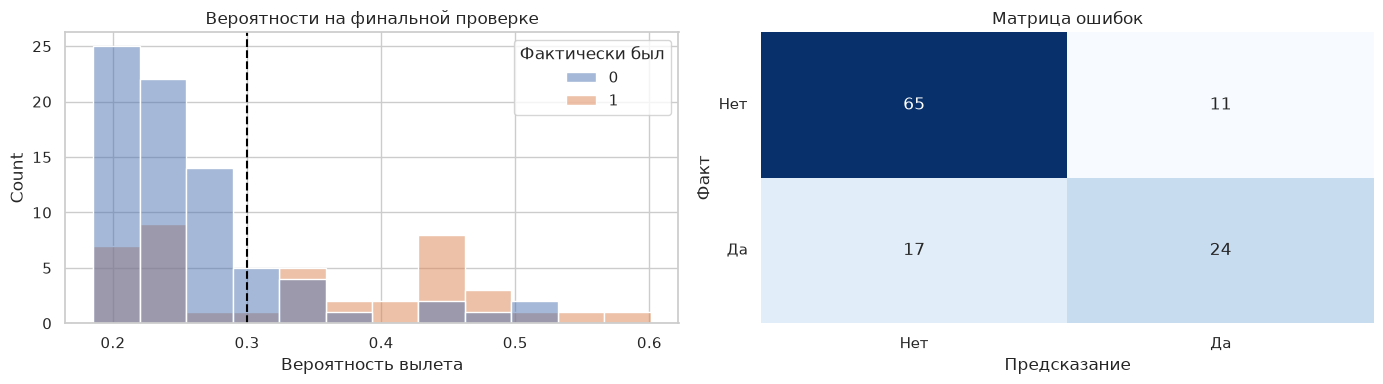

In [7]:
selected_predictions = model_predictions[model_predictions["Расчет"] == selected_name].copy()
selected_predictions["Ошибка"] = np.select(
    [
        (selected_predictions["Предсказал вылет"] == 1) & (selected_predictions["Фактически был"] == 0),
        (selected_predictions["Предсказал вылет"] == 0) & (selected_predictions["Фактически был"] == 1),
    ],
    ["ложное Да", "ложное Нет"],
    default="угадал",
)
selected_predictions["Месяц"] = pd.to_datetime(selected_predictions["date"]).dt.month

display(
    selected_predictions[selected_predictions["Ошибка"] != "угадал"]
    .sort_values(["Ошибка", "date"])
    [["date", "Ошибка", "Фактически был", "Предсказал вылет", "Вероятность вылета", "Порог"]]
    .round(4)
)

error_by_month = (
    selected_predictions.groupby(["Месяц", "Ошибка"])
    .size()
    .reset_index(name="Дней")
)
display(error_by_month)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=selected_predictions, x="Вероятность вылета", hue="Фактически был", bins=12, multiple="layer", ax=axes[0])
axes[0].axvline(float(selected_test["Порог"]), color="black", linestyle="--")
axes[0].set_title("Вероятности на финальной проверке")
axes[0].set_xlabel("Вероятность вылета")

conf = confusion_matrix(selected_predictions["Фактически был"], selected_predictions["Предсказал вылет"])
sns.heatmap(conf, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1])
axes[1].set_title("Матрица ошибок")
axes[1].set_xlabel("Предсказание")
axes[1].set_ylabel("Факт")
axes[1].set_xticklabels(["Нет", "Да"])
axes[1].set_yticklabels(["Нет", "Да"], rotation=0)
plt.tight_layout()
plt.show()

## Короткий вывод

Для дальнего прогноза без погоды текущую климатико-историческую оценку можно улучшить.

Выбранный вариант: **random_forest_depth6_leaf15** с порогом **0.30**.

Самое честное сравнение — не только с текущим порогом `45%`, но и со старой исторической формулой, у которой порог тоже подобран на проверочном периоде:

- итоговый балл выбранной модели: **0.725**;
- итоговый балл старой формулы с новым порогом: **0.511**;
- доля правильных ответов: **76.1%** против **56.4%**;
- сбалансированная точность: **72.0%** против **46.2%**;
- ложные “Да”: **11** против **15**;
- ложные “Нет”: **17** против **36**.

По сравнению с текущим порогом сервиса `45%` разница тоже большая: **76.1%** правильных ответов против **37.6%**, а ложных “Да” становится **11** вместо **71**. Но это сравнение менее строгое, потому что текущий порог явно неудачно работает на финальном периоде.

Вывод: `random_forest_depth6_leaf15` — хороший кандидат на замену климатико-исторической оценки для дальнего горизонта. Но выборка небольшая: в проверочном и финальном периодах по **117** дней, а доля выполненных рейсов в них отличается. Поэтому перед внедрением нужен следующий шаг: считать признаки по дате фактического прогноза и наблюдать качество на новых прогнозах.

Это не относится к ближайшим датам с погодой. Там сервис продолжает использовать погодные правила, табло и расписание. Здесь речь только о дальнем горизонте, где подробной погоды нет.
